In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv(r"C:\Users\user\Desktop\AI-ML-Projects\eeg-seizure-detection\data\Epileptic Seizure Recognition.csv")
df.shape
df.head

<bound method NDFrame.head of           Unnamed   X1   X2   X3   X4   X5   X6   X7   X8   X9  ...  X170  \
0      X21.V1.791  135  190  229  223  192  125   55   -9  -33  ...   -17   
1      X15.V1.924  386  382  356  331  320  315  307  272  244  ...   164   
2         X8.V1.1  -32  -39  -47  -37  -32  -36  -57  -73  -85  ...    57   
3       X16.V1.60 -105 -101  -96  -92  -89  -95 -102 -100  -87  ...   -82   
4       X20.V1.54   -9  -65  -98 -102  -78  -48  -16    0  -21  ...     4   
...           ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   ...   
11495  X22.V1.114  -22  -22  -23  -26  -36  -42  -45  -42  -45  ...    15   
11496  X19.V1.354  -47  -11   28   77  141  211  246  240  193  ...   -65   
11497    X8.V1.28   14    6  -13  -16   10   26   27   -9    4  ...   -65   
11498  X10.V1.932  -40  -25   -9  -12   -2   12    7   19   22  ...   121   
11499  X16.V1.210   29   41   57   72   74   62   54   43   31  ...   -59   

       X171  X172  X173  X174  X175  X176  X1

In [4]:
df['y'].value_counts()

y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64

Convert Y values to Binary Classification


In [5]:
df["y"] = df["y"].apply(
    lambda x: 1 
    if x ==1 
    else 0
)

In [6]:
df.head

<bound method NDFrame.head of           Unnamed   X1   X2   X3   X4   X5   X6   X7   X8   X9  ...  X170  \
0      X21.V1.791  135  190  229  223  192  125   55   -9  -33  ...   -17   
1      X15.V1.924  386  382  356  331  320  315  307  272  244  ...   164   
2         X8.V1.1  -32  -39  -47  -37  -32  -36  -57  -73  -85  ...    57   
3       X16.V1.60 -105 -101  -96  -92  -89  -95 -102 -100  -87  ...   -82   
4       X20.V1.54   -9  -65  -98 -102  -78  -48  -16    0  -21  ...     4   
...           ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   ...   
11495  X22.V1.114  -22  -22  -23  -26  -36  -42  -45  -42  -45  ...    15   
11496  X19.V1.354  -47  -11   28   77  141  211  246  240  193  ...   -65   
11497    X8.V1.28   14    6  -13  -16   10   26   27   -9    4  ...   -65   
11498  X10.V1.932  -40  -25   -9  -12   -2   12    7   19   22  ...   121   
11499  X16.V1.210   29   41   57   72   74   62   54   43   31  ...   -59   

       X171  X172  X173  X174  X175  X176  X1

In [14]:
x = df.drop(["y", "Unnamed"], axis=1)
y = df["y"]

In [15]:
x.head

<bound method NDFrame.head of         X1   X2   X3   X4   X5   X6   X7   X8   X9  X10  ...  X169  X170  \
0      135  190  229  223  192  125   55   -9  -33  -38  ...     8   -17   
1      386  382  356  331  320  315  307  272  244  232  ...   168   164   
2      -32  -39  -47  -37  -32  -36  -57  -73  -85  -94  ...    29    57   
3     -105 -101  -96  -92  -89  -95 -102 -100  -87  -79  ...   -80   -82   
4       -9  -65  -98 -102  -78  -48  -16    0  -21  -59  ...    10     4   
...    ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   ...   ...   
11495  -22  -22  -23  -26  -36  -42  -45  -42  -45  -49  ...    20    15   
11496  -47  -11   28   77  141  211  246  240  193  136  ...   -94   -65   
11497   14    6  -13  -16   10   26   27   -9    4   14  ...   -42   -65   
11498  -40  -25   -9  -12   -2   12    7   19   22   29  ...   114   121   
11499   29   41   57   72   74   62   54   43   31   23  ...   -94   -59   

       X171  X172  X173  X174  X175  X176  X177  X178  
0

In [16]:
x.shape

(11500, 178)

Train/Test Split

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
    
)

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

model = RandomForestClassifier(random_state=42, n_estimators=200)

# param_grid = {
#     "n_estimators": [100, 200, 300],
#     "max_depth": [None, 10, 20, 30],
#     "min_samples_split": [2,5,10],
#     "min_samples_leaf": [1,2,4],
#     "bootstrap": [True, False]
# }

# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     cv=5,
#     n_jobs=1,
#     verbose=2
# )

model.fit(x_train, y_train)
# print("Best parameters:", grid_search.best_params_)
# best_model = grid_search.best_estimator_



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
from sklearn.metrics import accuracy_score

pred = model.predict(x_test)

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.9808695652173913


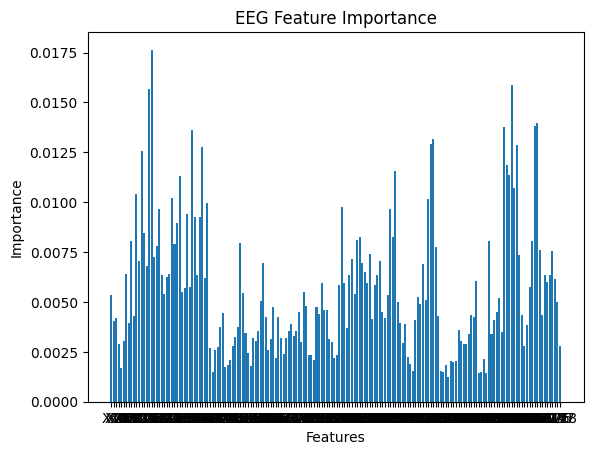

In [22]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.bar(x.columns, importance)

plt.title("EEG Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

In [25]:
prob = model.predict_proba(x_test)

print(prob[:5])

[[1.    0.   ]
 [0.985 0.015]
 [0.995 0.005]
 [1.    0.   ]
 [1.    0.   ]]


EEG Signal Visualization

Meaning Seizure probability = 98.5%

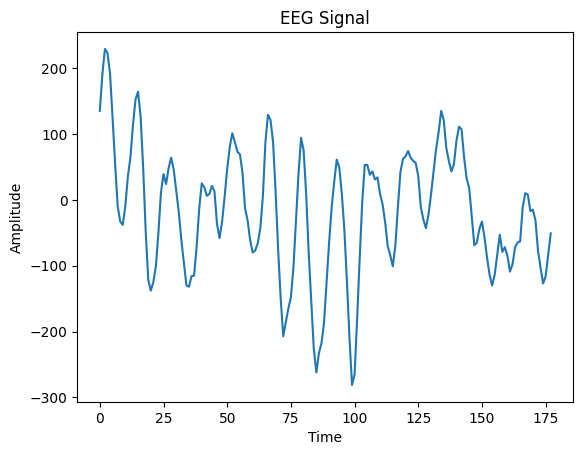

In [27]:
import matplotlib.pyplot as plt
import numpy as np

sample = x.iloc[0].values

plt.plot(sample)
plt.title("EEG Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

Compare seizure vs normal

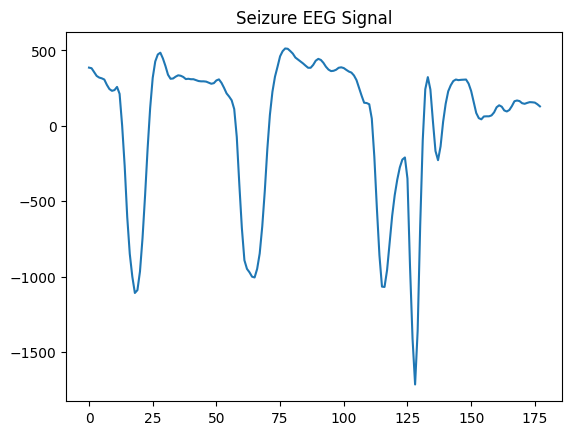

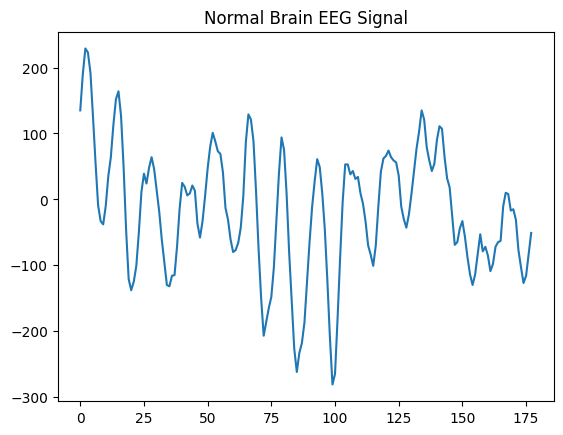

In [29]:
seizure_sample = x[y == 1].iloc[0]
normal_sample = x[y == 0].iloc[0]

plt.figure()

plt.plot(seizure_sample.values)
plt.title("Seizure EEG Signal")

plt.show()

plt.figure()

plt.plot(normal_sample.values)
plt.title("Normal Brain EEG Signal")

plt.show()

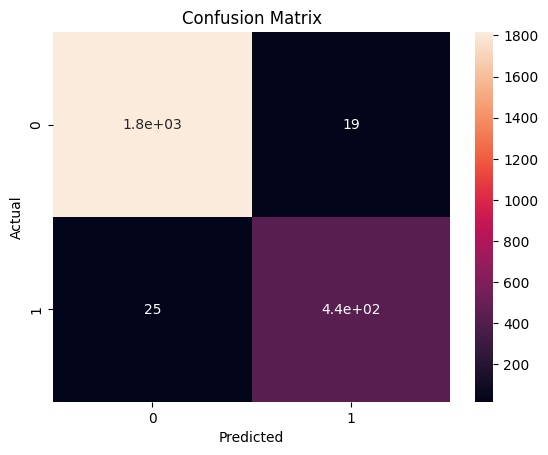

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [34]:
import pickle

with open("seizureWatch.ipynb.pkl", "wb") as f:
    pickle.dump(model, f)

Time-Domain Feature Extraction


Creating a function that extracts signal statistics.

In [35]:
import numpy as np
import pandas as pd

def extract_time_features(signal):
    
    features = {}

    features["mean"] = np.mean(signal)
    features["std"] = np.std(signal)
    features["max"] = np.max(signal)
    features["min"] = np.min(signal)
    features["range"] = np.max(signal) - np.min(signal)

    features["energy"] = np.sum(signal**2)

    features["skew"] = pd.Series(signal).skew()
    features["kurtosis"] = pd.Series(signal).kurtosis()

    return features

Apply to the Whole Dataset



extracting features for every EEG sample.

In [37]:
feature_list = []

for i in range(len(x)):
    
    signal = x.iloc[i].values
    
    feats = extract_time_features(signal)
    
    feature_list.append(feats)

feature_df = pd.DataFrame(feature_list)

print(feature_df.head())

        mean         std  max   min  range    energy      skew  kurtosis
0 -16.910112   95.710958  229  -281    510   1681484 -0.202033  0.103825
1  28.112360  471.835823  513 -1716   2229  39768644 -1.523960  1.414839
2 -44.044944   44.186380   80  -126    206    692846  0.498697 -0.212826
3 -68.910112   15.923723  -22  -105     83    890386  0.370253  0.252723
4  -6.651685   38.693001   78  -103    181    274368 -0.466683 -0.223217


Fast Fourier Transform (FFT) Feature Function

In [38]:
def extract_frequency_features(signal):

    fft_vals = np.fft.fft(signal)
    
    fft_vals = np.abs(fft_vals)

    features = {}

    features["fft_mean"] = np.mean(fft_vals)
    features["fft_std"] = np.std(fft_vals)
    features["fft_max"] = np.max(fft_vals)

    return features

Combine Time + Frequency Features

In [41]:
feature_list = []

for i in range(len(x)):
    
    signal = x.iloc[i].values
    
    time_feats = extract_time_features(signal)
    
    freq_feats = extract_frequency_features(signal)
    
    combined = {**time_feats, **freq_feats}
    
    feature_list.append(combined)

feature_df = pd.DataFrame(feature_list)

print(feature_df.head())

        mean         std  max   min  range    energy      skew  kurtosis  \
0 -16.910112   95.710958  229  -281    510   1681484 -0.202033  0.103825   
1  28.112360  471.835823  513 -1716   2229  39768644 -1.523960  1.414839   
2 -44.044944   44.186380   80  -126    206    692846  0.498697 -0.212826   
3 -68.910112   15.923723  -22  -105     83    890386  0.370253  0.252723   
4  -6.651685   38.693001   78  -103    181    274368 -0.466683 -0.223217   

      fft_mean      fft_std       fft_max  
0   637.242162  1129.338934   6547.031933  
1  3024.185590  5533.800278  31208.375473  
2   361.331587   749.856976   7840.000000  
3   198.617912   922.462425  12266.000000  
4   317.872983   416.322911   2595.209155  


In [42]:
from sklearn.model_selection import train_test_split

X_new = feature_df
y_new = y

X_train, X_test, y_train, y_test = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

In [44]:
from sklearn.metrics import accuracy_score

pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9808695652173913


Visualize EEG Frequency Spectrum

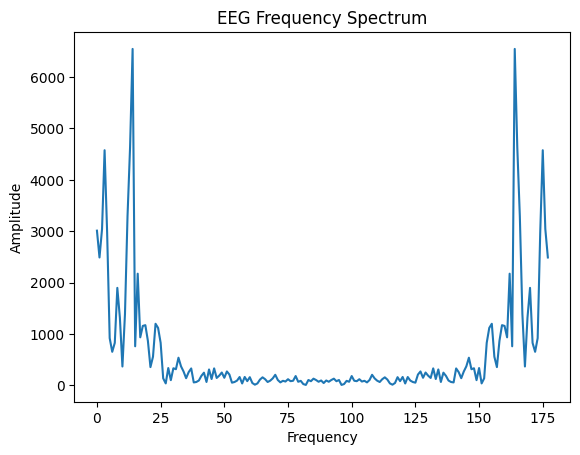

In [46]:
import matplotlib.pyplot as plt

signal = x.iloc[0].values

fft_vals = np.abs(np.fft.fft(signal))

plt.plot(fft_vals)

plt.title("EEG Frequency Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")

plt.show()